# Multiclass Classification Metrics

Precision, recall, and F1 were defined for two classes (positive vs negative) in the binary metrics notebook. With 3+ classes, "positive" isn't well-defined anymore — so these metrics need a strategy for combining per-class scores into one number. This notebook covers the confusion matrix at N×N size, and the `average=` parameter that controls how per-class metrics get combined.

## 0. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score,
    classification_report
)

## 1. Load the Data

The iris dataset: 3 species (setosa, versicolor, virginica) from 4 flower measurements. A clean, classic multiclass problem.

In [2]:
data = load_iris()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print(data.target_names)   # ['setosa' 'versicolor' 'virginica']
X.head()

['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [3]:
y.value_counts()

0    50
1    50
2    50
Name: count, dtype: int64

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2, stratify=y)
X_train.shape, X_test.shape

((120, 4), (30, 4))

## 2. Fit a Model

In [5]:
clf = LogisticRegression(max_iter=5000)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

## 3. The Confusion Matrix Is Now N×N

With 3 classes, the confusion matrix is 3×3, not 2×2. Row `i`, column `j` = number of samples of actual class `i` predicted as class `j`. The diagonal is what the model got right; everything off-diagonal is a specific kind of mistake (e.g. "actual versicolor, predicted virginica").

In [6]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]


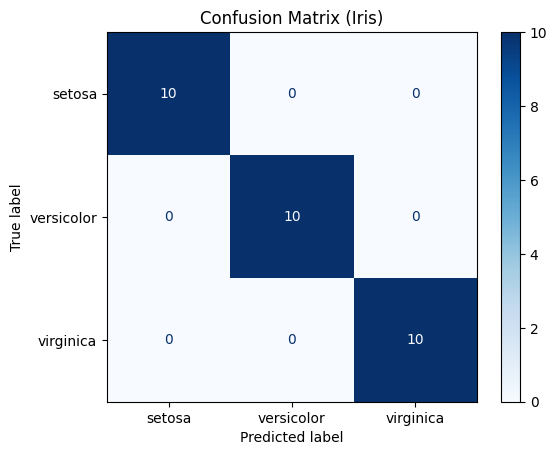

In [7]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix (Iris)')
plt.show()

## 4. Per-Class Metrics with `average=None`

Precision, recall, and F1 can still be computed — just **one score per class**, treating that class as "positive" and everything else as "negative" (one-vs-rest). `average=None` returns the raw per-class array, in class order.

In [8]:
precision_per_class = precision_score(y_test, y_pred, average=None)
recall_per_class = recall_score(y_test, y_pred, average=None)
f1_per_class = f1_score(y_test, y_pred, average=None)

pd.DataFrame({
    'class': data.target_names,
    'precision': precision_per_class,
    'recall': recall_per_class,
    'f1': f1_per_class
})

,class,precision,recall,f1
0,setosa,1.0,1.0,1.0
1,versicolor,1.0,1.0,1.0
2,virginica,1.0,1.0,1.0


## 5. Combining Per-Class Scores: `average=` Options

Usually you want one overall number, not one per class. The `average` parameter controls how the per-class scores get combined:

| Option | What it does | When to use |
|---|---|---|
| `'macro'` | Plain average across classes — every class weighted equally | All classes matter equally, regardless of how many samples each has |
| `'weighted'` | Average weighted by how many true samples each class has | Classes are imbalanced and you want the score to reflect that |
| `'micro'` | Aggregate TP/FP/FN across all classes first, then compute one score | You care about overall correctness across all predictions, not per-class balance |

In [9]:
for avg in ['macro', 'weighted', 'micro']:
    p = precision_score(y_test, y_pred, average=avg)
    r = recall_score(y_test, y_pred, average=avg)
    f = f1_score(y_test, y_pred, average=avg)
    print(f"{avg:>9}:  precision={p:.4f}  recall={r:.4f}  f1={f:.4f}")

    macro:  precision=1.0000  recall=1.0000  f1=1.0000
 weighted:  precision=1.0000  recall=1.0000  f1=1.0000
    micro:  precision=1.0000  recall=1.0000  f1=1.0000


On a balanced dataset like iris (50 samples per class), macro and weighted come out very close — the difference only shows up clearly when classes are imbalanced.

## 6. `classification_report()` — the All-in-One View

Rather than calling precision/recall/F1 separately for every averaging strategy, `classification_report` prints per-class metrics plus macro and weighted averages in one readable table.

In [10]:
print(classification_report(y_test, y_pred, target_names=data.target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



---
## Multiclass Classification Metrics Cheat Sheet

### Confusion Matrix
| Code | Description |
|---|---|
| `confusion_matrix(y_test, y_pred)` | Returns an N×N matrix for N classes |
| `ConfusionMatrixDisplay(cm, display_labels=...).plot()` | Visualize it with labels |

### Metrics with Averaging
| Code | Description |
|---|---|
| `precision_score(y_test, y_pred, average=None)` | One score per class |
| `precision_score(y_test, y_pred, average='macro')` | Unweighted mean across classes |
| `precision_score(y_test, y_pred, average='weighted')` | Mean weighted by class support (sample count) |
| `precision_score(y_test, y_pred, average='micro')` | Global TP/FP/FN pooled across classes, then one score |
| `classification_report(y_test, y_pred, target_names=...)` | Per-class + macro/weighted summary in one table |

### Gotchas
- `average=None` returns an array — don't forget to specify an averaging strategy when you actually want one number.
- `'macro'` treats a rare class exactly as important as a common one — can look misleadingly bad/good on imbalanced data.
- `'weighted'` is usually the safer default for imbalanced multiclass problems.
- `'micro'` averaged precision, recall, and F1 are all equal to each other and to accuracy in the single-label multiclass case — a good sanity check if the numbers ever match unexpectedly.